polyfit is better
Poly MSE: 0.07573244295304567, Poly R-squared: 0.039164496986296315
Lstsq MSE: 0.07861882664037183, Lstsq R-squared: 0.0025442611407147098


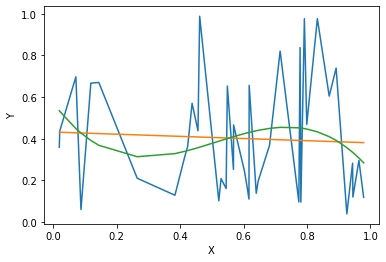

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)     

X = np.sort(np.random.rand(40)) 
Y = np.random.rand(40)  

A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
bfl = m * X + c

coefficients = np.polyfit(X, Y, 3)
poly = np.polyval(coefficients, X)

mse_lstsq = np.mean((Y - bfl) ** 2)
mse_poly = np.mean((Y - poly) ** 2)

tot = np.sum((Y - np.mean(Y)) ** 2)

res_lstsq = np.sum((Y - bfl) ** 2)
r2_lstsq = 1 - res_lstsq / tot

res_poly = np.sum((Y - poly) ** 2)
r2_poly = 1 - res_poly / tot

if mse_poly < mse_lstsq and r2_poly > r2_lstsq:
    print("polyfit is better")
elif mse_lstsq < mse_poly and r2_lstsq > r2_poly:
    print("Lstsq is better")
else:
    print("neither is best")

print(f"Poly MSE: {mse_poly}, Poly R-squared: {r2_poly}")
print(f"Lstsq MSE: {mse_lstsq}, Lstsq R-squared: {r2_lstsq}")

plt.figure()
plt.plot(X, Y)
plt.plot(X, bfl)
plt.plot(X, poly)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Part A: polyfit is better

degree 3: polyfit is better
degree 3 Poly MSE: 0.07573244295304567, Poly R-squared: 0.039164496986296315


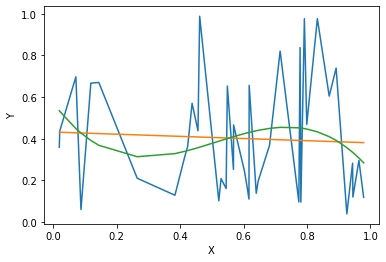

degree 4: polyfit is better
degree 4 Poly MSE: 0.06778008299551004, Poly R-squared: 0.1400579777985047


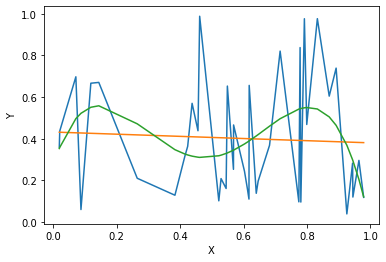

degree 5: polyfit is better
degree 5 Poly MSE: 0.0653521967644097, Poly R-squared: 0.17086114744622982


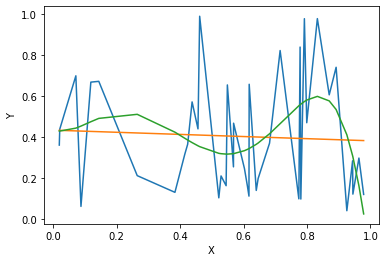

degree 6: polyfit is better
degree 6 Poly MSE: 0.06470441218800045, Poly R-squared: 0.17907974432557006


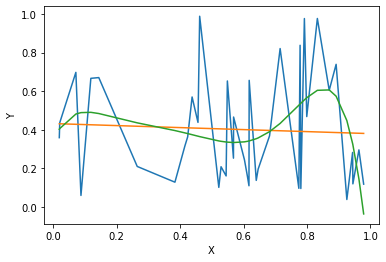

degree 7: polyfit is better
degree 7 Poly MSE: 0.06182088607044671, Poly R-squared: 0.21566372550429247


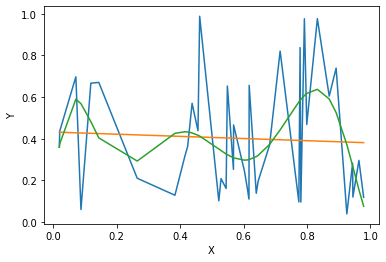

degree 2: polyfit is better
degree 2 Poly MSE: 0.07861199301063607, Poly R-squared: 0.002630961025315681


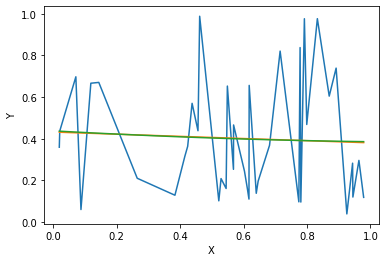

degree 1: neither is best
degree 1 Poly MSE: 0.07861882664037183, Poly R-squared: 0.0025442611407147098


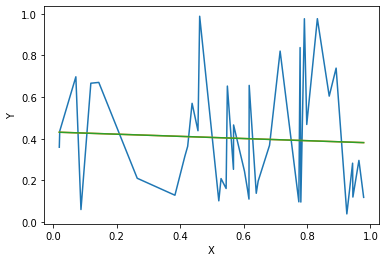

In [2]:
for d in [3, 4, 5, 6, 7, 2, 1]:
    coefficients1 = np.polyfit(X, Y, d)
    poly1 = np.polyval(coefficients1, X)

    mse_poly1 = np.mean((Y - poly1) ** 2)

    res_poly1 = np.sum((Y - poly1) ** 2)
    r2_poly1 = 1 - res_poly1 / tot

    if mse_poly1 < mse_lstsq and r2_poly1 > r2_lstsq:
        print(f"degree {d}: polyfit is better")
    elif mse_lstsq < mse_poly1 and r2_lstsq > r2_poly1:
        print(f"degree {d}: lstsq is better")
    else:
        print(f"degree {d}: neither is best")

    print(f"degree {d} Poly MSE: {mse_poly1}, Poly R-squared: {r2_poly1}")

    plt.figure()
    plt.plot(X, Y)
    plt.plot(X, bfl)
    plt.plot(X, poly1)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

At degree 5 it starts blatantly overfitting. Even at degree 1 its the same as the lstsq fit. 

Vandermonde polynomial is better
Vandermonde coefficients: [ 0.43812382 -0.08487991  0.0325973 ]
Poly MSE: 0.07861199301063607, Poly R-squared: 0.002630961025315681
Lstsq MSE: 0.07861882664037183, Lstsq R-squared: 0.0025442611407147098


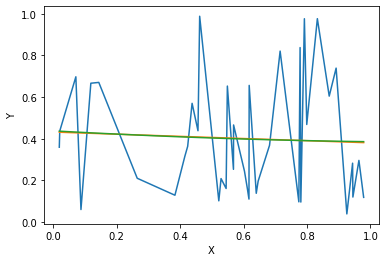

Vandermonde polynomial is better
Vandermonde coefficients: [ 0.57154332 -2.05781507  4.94676127 -3.21239099]
Poly MSE: 0.07573244295304567, Poly R-squared: 0.039164496986296315
Lstsq MSE: 0.07861882664037183, Lstsq R-squared: 0.0025442611407147098


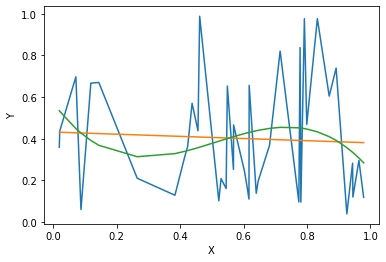

Vandermonde polynomial is better
Vandermonde coefficients: [  0.27462017   4.61033295 -23.56203195  39.30363408 -20.64590566]
Poly MSE: 0.0677800829955102, Poly R-squared: 0.1400579777985027
Lstsq MSE: 0.07861882664037183, Lstsq R-squared: 0.0025442611407147098


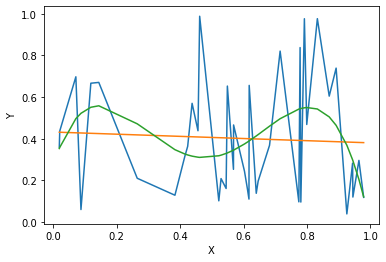

Vandermonde polynomial is better
Vandermonde coefficients: [  0.43518241  -0.61627533  13.9906416  -61.43699132  92.83346067
 -45.42534449]
Poly MSE: 0.06535219676440931, Poly R-squared: 0.17086114744623493
Lstsq MSE: 0.07861882664037183, Lstsq R-squared: 0.0025442611407147098


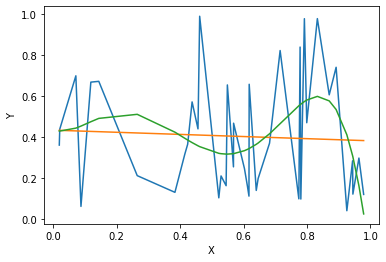

Vandermonde polynomial is better
Vandermonde coefficients: [   0.34355426    3.74829921  -33.58570413  133.9006276  -276.35845764
  280.47243495 -108.89336543]
Poly MSE: 0.06470441218800135, Poly R-squared: 0.1790797443255584
Lstsq MSE: 0.07861882664037183, Lstsq R-squared: 0.0025442611407147098


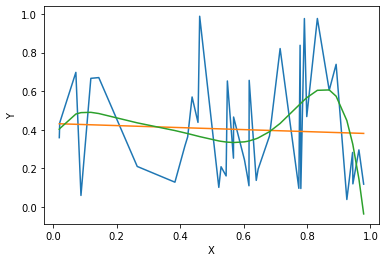

neither is clearly better
Vandermonde coefficients: [ 0.43240531 -0.05198716]
Poly MSE: 0.07861882664037183, Poly R-squared: 0.0025442611407147098
Lstsq MSE: 0.07861882664037183, Lstsq R-squared: 0.0025442611407147098


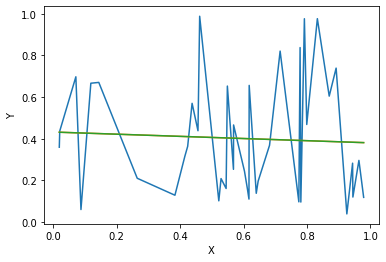

Linear lstsq is better
Vandermonde coefficients: [0.40252828]
Poly MSE: 0.07881936368453024, Poly R-squared: 0.0
Lstsq MSE: 0.07861882664037183, Lstsq R-squared: 0.0025442611407147098


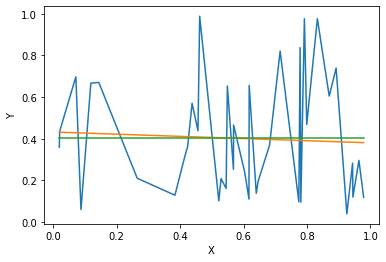

In [3]:
for d in [3, 4, 5, 6, 7, 2, 1]:
    V = np.vander(X, N= d, increasing=True)

    VT_V = np.dot(V.T, V)
    VT_Y = np.dot(V.T, Y)

    coefficients2 = np.linalg.solve(VT_V, VT_Y)

    poly2 = np.dot(V, coefficients2)

    mse_lstsq = np.mean((Y - bfl) ** 2)
    mse_poly2 = np.mean((Y - poly2) ** 2)

    res_poly2 = np.sum((Y - poly2) ** 2)
    r2_poly2 = 1 - res_poly2 / tot

    if mse_poly2 < mse_lstsq and r2_poly2 > r2_lstsq:
        print("Vandermonde polynomial is better")
    elif mse_lstsq < mse_poly2 and r2_lstsq > r2_poly2:
        print("Linear lstsq is better")
    else:
        print("neither is best")

    print("Vandermonde coefficients:", coefficients2)
    print(f"Poly MSE: {mse_poly2}, Poly R-squared: {r2_poly2}")
    print(f"Lstsq MSE: {mse_lstsq}, Lstsq R-squared: {r2_lstsq}")

    plt.figure()
    plt.plot(X, Y)
    plt.plot(X, bfl)
    plt.plot(X, poly2)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

Its almost the same but Vandermonde with degree 0 is worse than the lstsq fit as its just a y=c line. 